# AICE Associate 모의고사 5회 — 교통량 예측 수정판

> 난이도: Level 3 — 실제 시험 수준  
> 목표 변수: `VehicleCount_per_hour`

이 노트북은 **문제만 포함**되어 있으며, 각 문항 아래 빈 코드 셀에 직접 답을 작성하면 됩니다.


## 5-1. 라이브러리 임포트 및 데이터 로딩

다음 조건에 맞게 코드를 작성하세요.

- `pandas`를 `pd`라는 별칭으로 임포트하세요.
- `traffic_sensors.json` 파일을 읽어 `df_traffic`에 저장하세요.
- `event_data.csv` 파일을 읽어 `df_event`에 저장하세요.


In [149]:
# 라이브러리 임포트
import pandas as pd

In [150]:
# 데이터 불러오기
df_traffic = pd.read_json('C:/juehyeon/aice_test/기출문제/5.교통량예측/traffic_sensors.json')
df_event = pd.read_csv('C:/juehyeon/aice_test/기출문제/5.교통량예측/event_data.csv')

In [151]:
# 데이터 확인하기
df_traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   SensorID               200 non-null    int64         
 1   Timestamp              200 non-null    datetime64[ns]
 2   VehicleCount_per_hour  200 non-null    int64         
 3   AverageSpeed_kmh       200 non-null    float64       
 4   RoadType               200 non-null    object        
 5   WeatherCondition       200 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 9.5+ KB


In [152]:
# 데이터 확인하기
df_event.info() # 결측치 확인 -> SensorId, EventType, EventSeverity

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SensorID       196 non-null    float64
 1   Timestamp      200 non-null    object 
 2   EventType      125 non-null    object 
 3   EventSeverity  108 non-null    float64
dtypes: float64(2), object(2)
memory usage: 6.4+ KB


## 5-2. Timestamp 타입 변환 및 데이터 병합

다음 조건에 맞게 코드를 작성하세요.

- `df_traffic`과 `df_event`의 `Timestamp` 컬럼을 모두 `datetime` 타입으로 변환하세요.
- `SensorID`, `Timestamp` 두 컬럼을 병합 키로 사용하세요.
- `df_traffic`을 기준으로 `left` 병합하세요.
- 병합 결과를 `df` 변수에 저장하세요.

**주의:** 병합 키의 데이터 타입을 먼저 통일한 후 병합하세요.


In [153]:
# 데이터 타입 확인
df_event['Timestamp'].dtype

dtype('O')

In [154]:
# 데이터 변환
df_event['Timestamp'] = pd.to_datetime(df_event['Timestamp'])

In [155]:
# 데이터 변환 확인
df_event.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   SensorID       196 non-null    float64       
 1   Timestamp      200 non-null    datetime64[ns]
 2   EventType      125 non-null    object        
 3   EventSeverity  108 non-null    float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 6.4+ KB


In [156]:
# 데이터 병합
df = pd.merge(df_traffic, df_event, on = ['SensorID', 'Timestamp'], how = 'left')

In [157]:
# 데이터 병합 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   SensorID               200 non-null    int64         
 1   Timestamp              200 non-null    datetime64[ns]
 2   VehicleCount_per_hour  200 non-null    int64         
 3   AverageSpeed_kmh       200 non-null    float64       
 4   RoadType               200 non-null    object        
 5   WeatherCondition       200 non-null    object        
 6   EventType              8 non-null      object        
 7   EventSeverity          6 non-null      float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 12.6+ KB


## 5-3. 시간 파생변수 생성 및 불필요 컬럼 삭제

`df`의 `Timestamp`를 이용하여 다음 파생변수를 생성하세요.

- `Hour`: 시간
- `DayOfWeek`: 요일을 `0~6`의 숫자로 표현
  - 월요일 = 0
  - 일요일 = 6

파생변수를 만든 후 다음 컬럼을 삭제하세요.

- `Timestamp`
- `SensorID`


In [158]:
# 파생변수 생성
df['Hour'] = df['Timestamp'].dt.hour

In [159]:
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

In [160]:
df.head()

,SensorID,Timestamp,VehicleCount_per_hour,AverageSpeed_kmh,RoadType,WeatherCondition,EventType,EventSeverity,Hour,DayOfWeek
0,7,2024-01-01 00:00:00,111,65.9,Highway,Snow,NaN,NaN,0,0
1,7,2024-01-01 03:00:00,64,57.6,Urban,Snow,NaN,NaN,3,0
2,5,2024-01-01 06:00:00,72,88.2,Residential,Rain,NaN,NaN,6,0
3,6,2024-01-01 09:00:00,279,41.0,Urban,Fog,NaN,NaN,9,0
4,10,2024-01-01 12:00:00,198,61.5,Urban,Clear,NaN,NaN,12,0


In [161]:
# 컬럼 삭제
del_cols = ['Timestamp', 'SensorID']
df = df.drop(columns = del_cols, axis = 1)

In [162]:
# 컬럼 확인
df.columns

Index(['VehicleCount_per_hour', 'AverageSpeed_kmh', 'RoadType',
       'WeatherCondition', 'EventType', 'EventSeverity', 'Hour', 'DayOfWeek'],
      dtype='object')

## 5-4. 결측치 처리

다음 조건에 따라 결측치를 처리하세요.

### EventSeverity
- `EventSeverity`의 결측치를 해당 컬럼의 **중앙값(median)**으로 대체하세요.

### EventType
- `EventType`의 결측치를 문자열 `'NoEvent'`로 대체하세요.

**주의:** `EventType`을 최빈값인 `Accident` 등으로 채우지 마세요.


In [163]:
# 결측치 확인
df['EventSeverity'].isna().sum()

np.int64(194)

In [164]:
# 결측치 대체
df['EventSeverity'] = df['EventSeverity'].fillna(df['EventSeverity'].median())

In [165]:
# 결측치 확인
df['EventSeverity'].isna().sum()

np.int64(0)

In [166]:
# 결측치 확인 2
df['EventType'].isna().sum()

np.int64(192)

In [167]:
# 결측치 대체 2
df['EventType'] = df['EventType'].fillna('NoEvent')

In [168]:
# 결측치 확인 2
df['EventType'].isna().sum()

np.int64(0)

## 5-5. 범주형 변수 분포 시각화

`matplotlib.pyplot`과 `seaborn`을 사용하세요.

다음 두 컬럼의 빈도 분포를 **각각 별도의 그래프**로 시각화하세요.

- `RoadType`
- `WeatherCondition`

조건:
- `seaborn`의 `countplot` 사용
- 각 그래프마다 `plt.figure()` 사용
- 적절한 제목 지정
- 각 그래프를 `plt.show()`로 출력


In [169]:
# 라이브러리 임포트
import matplotlib.pyplot as plt
import seaborn as sns

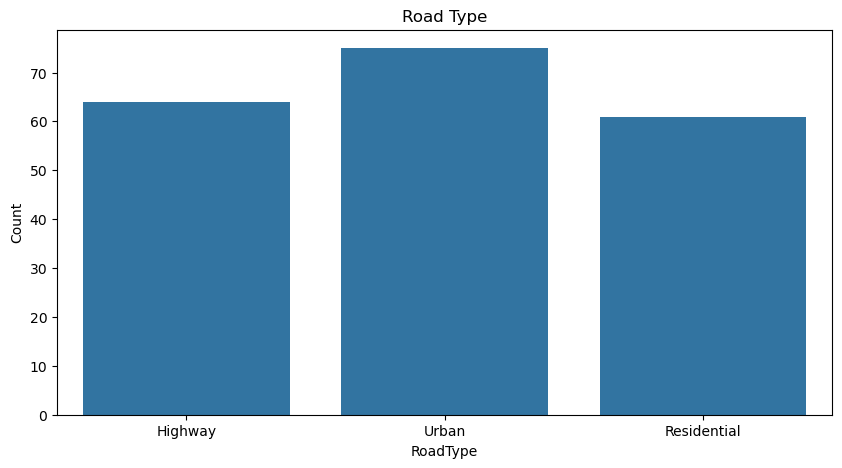

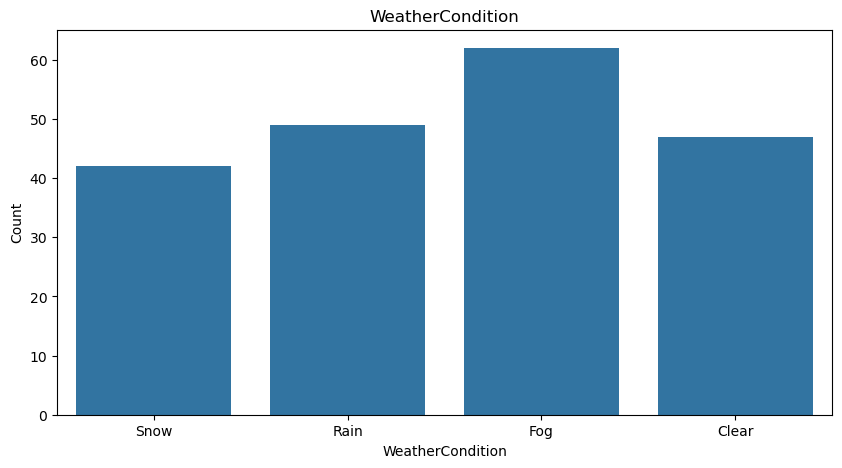

In [170]:
# 그래프 시각화
# Road Type
plt.figure(figsize = (10, 5))
sns.countplot(data = df, x = 'RoadType')
plt.title('Road Type')
plt.xlabel('RoadType')
plt.ylabel('Count')
plt.show()
# Weather Condition
plt.figure(figsize = (10, 5))
sns.countplot(data = df, x = 'WeatherCondition')
plt.title('WeatherCondition')
plt.xlabel('WeatherCondition')
plt.ylabel('Count')
plt.show()

## 5-6. 범주형 변수 원-핫 인코딩

다음 세 컬럼을 원-핫 인코딩하세요.

- `RoadType`
- `WeatherCondition`
- `EventType`

조건:
- `pandas.get_dummies()` 사용
- 결과를 `df_encoded` 변수에 저장
- 원본 범주형 컬럼은 인코딩된 컬럼으로 대체
- `drop_first`는 사용하지 않아도 됩니다.


In [171]:
# 원-핫 인코딩
incod_cols = ['RoadType', 'WeatherCondition', 'EventType']
df = pd.get_dummies(data = df, columns = incod_cols)

In [172]:
# 인코딩 확인
df.columns

Index(['VehicleCount_per_hour', 'AverageSpeed_kmh', 'EventSeverity', 'Hour',
       'DayOfWeek', 'RoadType_Highway', 'RoadType_Residential',
       'RoadType_Urban', 'WeatherCondition_Clear', 'WeatherCondition_Fog',
       'WeatherCondition_Rain', 'WeatherCondition_Snow', 'EventType_Accident',
       'EventType_Construction', 'EventType_NoEvent'],
      dtype='object')

In [173]:
# 변수 재할당
df_encoded = df.copy()

## 5-7. X와 y 분리 및 학습/검증 데이터 분리

최종 교통량인 `VehicleCount_per_hour`를 예측합니다.

다음 조건에 맞게 데이터를 구성하세요.

- `VehicleCount_per_hour` → `y`
- 나머지 모든 컬럼 → `X`

`train_test_split()`을 사용하여 다음 비율로 분리하세요.

- 훈련 데이터: 80%
- 검증 데이터: 20%
- `random_state=42`

결과 변수명:
- `X_train`
- `X_valid`
- `y_train`
- `y_valid`


In [174]:
# 타겟 데이터 분리
X = df_encoded.drop(columns = 'VehicleCount_per_hour')
y = df_encoded['VehicleCount_per_hour']

In [175]:
# 라이브러리 임포트
from sklearn.model_selection import train_test_split

In [176]:
# 훈련, 검증 데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(X, y, 
                                                      random_state = 42, 
                                                      test_size = 0.2)

In [177]:
# 데이터분리 확인
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

(160, 14) (40, 14) (160,) (40,)


## 5-8. MinMaxScaler를 이용한 데이터 스케일링

`sklearn.preprocessing.MinMaxScaler`를 사용하세요.

조건:
- 스케일러 객체명: `scaler`
- `X_train`에는 `fit_transform()`
- `X_valid`에는 `transform()`

결과 변수명:
- `X_train_scaled`
- `X_valid_scaled`

**주의:** 검증 데이터에 `fit_transform()`을 사용하지 마세요.


In [178]:
# 라이브러리 임포트
from sklearn.preprocessing import MinMaxScaler
# 모델 객체 생성
scaler = MinMaxScaler()

In [179]:
# 데이터 스케일링
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

## 5-9. Ridge 회귀 모델

`sklearn.linear_model.Ridge`를 이용하여 회귀 모델을 생성하세요.

조건:
- `alpha=1.0`
- 모델명: `ridge_model`
- 학습 데이터:
  - `X_train_scaled`
  - `y_train`


In [180]:
# 라이브러리 임포트
from sklearn.linear_model import Ridge

In [181]:
# 모델 객체 생성
ridge_model = Ridge(alpha = 1.0)

In [182]:
# 모델 학습
ridge_model.fit(X_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


## 5-10. XGBoost 회귀 모델

`xgboost.XGBRegressor`를 이용하여 모델을 생성하세요.

조건:
- `n_estimators=500`
- `learning_rate=0.05`
- `random_state=42`
- 모델명: `xgb_model`

`X_train_scaled`, `y_train`을 이용하여 학습하세요.


In [183]:
# 라이브러리 임포트 
from xgboost import XGBRegressor 
# 모델 생성
xgb_model = XGBRegressor(n_estimators = 500, learning_rate = 0.05, random_state = 42)

In [184]:
# 모델 학습
xgb_model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## 5-11. 딥러닝 모델 생성 및 기본 학습

`tensorflow.keras`를 이용하여 회귀 모델을 만드세요.

### 모델 구조
입력층 이후 히든 레이어를 다음과 같이 구성하세요.

- 첫 번째 Hidden Layer: `128`개 뉴런, `relu`
- 두 번째 Hidden Layer: `64`개 뉴런, `relu`
- 세 번째 Hidden Layer: `32`개 뉴런, `relu`

출력층:
- 뉴런 수: `1`
- 활성화 함수: `linear`

모델 객체명은 `model`로 지정하세요.

### Compile 조건
- optimizer: `adam`
- loss: `mse`
- metrics: `mae`

### 학습 조건
- 입력: `X_train_scaled`
- 정답: `y_train`
- 검증 데이터: `(X_valid_scaled, y_valid)`
- `epochs=100`
- `batch_size=32`
- 학습 결과를 `history` 변수에 저장


In [185]:
# 라이브러리 임포트
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

In [186]:
# 모델 생성
model = Sequential([
    Input(shape = (X_train_scaled.shape[1], )),
    Dense(128, activation = 'relu'),
    Dense(64, activation = 'relu'),
    Dense(32, activation = 'relu'),
    Dense(1, activation = 'linear')
])

In [187]:
# 모델 컴파일
model.compile(
    optimizer = 'adam',
    loss = 'mse', 
    metrics = ['mae']
)

In [188]:
# 모델 학습
history = model.fit(
    X_train_scaled,
    y_train,
    epochs = 100, 
    batch_size = 32, 
    validation_data = (X_valid_scaled, y_valid)
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - loss: 29465.7930 - mae: 147.9368 - val_loss: 30822.4180 - val_mae: 151.8804
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 29358.0664 - mae: 147.5909 - val_loss: 30704.5586 - val_mae: 151.5041
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 29226.5000 - mae: 147.1407 - val_loss: 30529.7871 - val_mae: 150.9466
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 29011.6660 - mae: 146.4486 - val_loss: 30264.5879 - val_mae: 150.0865
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 28690.6934 - mae: 145.3733 - val_loss: 29848.7930 - val_mae: 148.7275
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 28211.6348 - mae: 143.7166 - val_loss: 29218.7598 - val_mae: 146.6529
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 27487.9727 - mae: 141.2205 - val_loss: 28301.1406 - val_mae: 143.5707
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 26420.5684 - mae: 137.5785 - val_loss: 26996.

## 5-12. 딥러닝 학습 성능 시각화

5-11의 `history`를 이용하여 다음 두 값을 하나의 그래프에 표시하세요.

- 학습 MAE → `'Training MAE'`
- 검증 MAE → `'Validation MAE'`

조건:
- x축: `Epochs`
- y축: `MAE`
- 범례 표시
- 그래프 출력


In [189]:
# 학습기록 확인하기
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

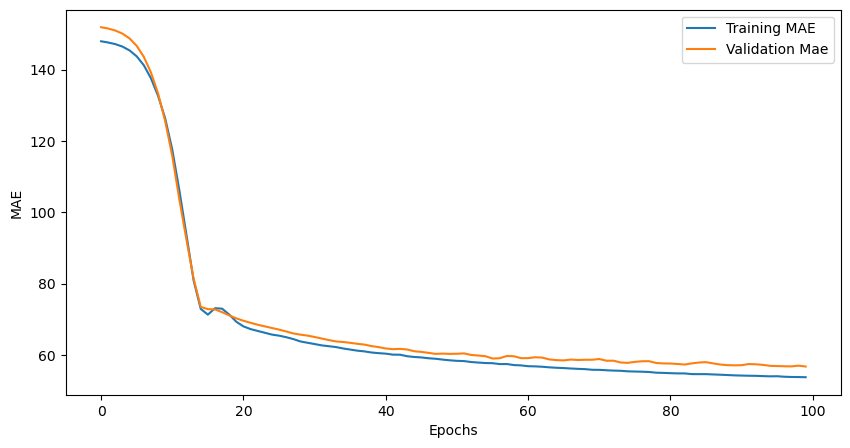

In [190]:
plt.figure(figsize = (10,5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label = 'Validation Mae')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

## 5-13. EarlyStopping을 적용한 딥러닝 모델

이번에는 **5-11과 동일한 구조의 새로운 모델**을 생성하여 EarlyStopping을 적용하세요.

새 모델명:
- `model_es`

모델 구조와 compile 조건은 5-11과 동일합니다.

`EarlyStopping` 객체를 다음 조건으로 생성하세요.

- `monitor='val_loss'`
- `patience=5`
- `restore_best_weights=True`

콜백 객체명:
- `early_stopping`

`model_es`를 다음 조건으로 학습하세요.

- 훈련 데이터: `X_train_scaled`, `y_train`
- 검증 데이터: `(X_valid_scaled, y_valid)`
- `epochs=100`
- `batch_size=32`
- `callbacks`에 `early_stopping` 적용
- 학습 결과는 `history_es`에 저장

**주의:** 기존 `model`을 이어서 학습하지 말고 새 모델 `model_es`를 만드세요.


In [191]:
# 라이브러리 임포트
from tensorflow.keras.callbacks import EarlyStopping

In [192]:
# 콜백 생성
early_stopping = EarlyStopping(
                        monitor = 'val_loss',
                        patience = 5,
                        restore_best_weights = True
                    )

In [193]:
# 모델 생성
model_es = Sequential([
    Input(shape = (X_train_scaled.shape[1],)),
    Dense(128, activation = 'relu'),
    Dense(64, activation = 'relu'),
    Dense(32, activation = 'relu'),
    Dense(1, activation = 'linear')
])

In [194]:
# 모델 컴파일
model_es.compile(
    optimizer = 'adam',
    loss = 'mse', 
    metrics = ['mae']
)

In [195]:
# 모델 학습
history_es = model_es.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_valid_scaled, y_valid),  
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]                  
)
    

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 276ms/step - loss: 29502.3535 - mae: 148.0738 - val_loss: 30830.1562 - val_mae: 151.9186
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 29366.4375 - mae: 147.6212 - val_loss: 30701.2344 - val_mae: 151.5010
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 29228.5059 - mae: 147.1617 - val_loss: 30534.5312 - val_mae: 150.9603
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 29040.8125 - mae: 146.5193 - val_loss: 30289.5879 - val_mae: 150.1643
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - loss: 28763.5000 - mae: 145.5835 - val_loss: 29933.3125 - val_mae: 148.9977
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - loss: 28352.7188 - mae: 144.2003 - val_loss: 29407.1406 - val_mae: 147.2584
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 27746.3320 - mae: 142.1350 - val_loss: 28634.4883 - val_mae: 144.6779
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 26879.3965 - mae: 139.1053 - val_loss: 275

## 5-14. 세 모델의 성능 평가

최종적으로 다음 세 모델을 비교합니다.

- `ridge_model`
- `xgb_model`
- `model_es`

각 모델을 이용하여 `X_valid_scaled`의 값을 예측하세요.

예측 결과 변수명:
- `ridge_pred`
- `xgb_pred`
- `dl_pred`

각 모델에 대해 다음 두 평가 지표를 계산하세요.

- `R²`
- `MAE`

사용 함수:
- `r2_score`
- `mean_absolute_error`

각 모델의 결과를 출력하세요.

### 최종 모델 선정 기준
- **R² → 클수록 좋음**
- **MAE → 작을수록 좋음**

두 지표가 서로 다른 모델을 가리키는 경우에는 결과를 모두 비교하고 이유를 설명하세요.


In [196]:
# 데이터 예측
ridge_pred = ridge_model.predict(X_valid_scaled)
xgb_pred = xgb_model.predict(X_valid_scaled)
dl_pred = model_es.predict(X_valid_scaled)
# 라이브러리 임포트
from sklearn.metrics import r2_score, mean_absolute_error

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step


In [197]:
# 평가
## r2
ridge_r2 = r2_score(y_valid, ridge_pred)
xgb_r2 = r2_score(y_valid, xgb_pred)
dl_r2 = r2_score(y_valid, dl_pred)
## mae 
ridge_mae = mean_absolute_error(y_valid, ridge_pred)
xgb_mae = mean_absolute_error(y_valid, xgb_pred)
dl_mae = mean_absolute_error(y_valid, dl_pred)

In [198]:
# 출력
print(f'Ridge - r2 Score: {ridge_r2}, mae : {ridge_mae}')
print(f'XGB - r2 Score: {xgb_r2}, mae : {xgb_mae}')
print(f'Deep Learning - r2 Score : {dl_r2}, mae : {dl_mae}')

Ridge - r2 Score: 0.4126154590303388, mae : 56.5804381918344
XGB - r2 Score: 0.898470938205719, mae : 22.650768280029297
Deep Learning - r2 Score : 0.414655864238739, mae : 56.251914978027344


In [199]:
# 최종 모델 선정
print(f'최종 모델 : XGBoost')

최종 모델 : XGBoost
